# ⏪ Actividad 03: Generación de Rezagos Temporales (Lags)
---
**Módulo 2: Feature Engineering para LSTM**

Las redes LSTM aprenden patrones en secuencias, pero necesitan que esas secuencias estén *explícitamente* representadas como columnas de entrada. Al agregar rezagos (`t-1`, `t-3`, `t-6`, `t-12`) convertimos nuestro dataset en una **ventana deslizante** que le muestra al modelo qué ocurrió 1, 3, 6 y 12 meses atrás para cada variable clave.

## 🎯 Objetivos
1. **Ordenar** el dataset cronológicamente por provincia/departamento.
2. **Generar rezagos** (`t-1`, `t-3`, `t-6`, `t-12`) para variables objetivo y variables exógenas (clima NASA y sentimiento NLP), **agrupando por provincia** para no mezclar series distintas.
3. **Eliminar NaNs** introducidos por el rezago en las primeras filas de cada provincia (estrategia `dropna`).
4. **Exportar** el dataset enriquecido con lags.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración estética
sns.set_theme(style='whitegrid', palette='viridis')
%matplotlib inline

# ── Rutas ──────────────────────────────────────────────────────────────────────
# Fuente: dataset_integrado.csv (Fase 1) + nlp_sentiment + codificación cíclica
INPUT_FILE  = '../../data/processed/dataset_fase2_base_completo.csv'
OUTPUT_FILE = '../../data/processed/master_dataset_fase2_lags.csv'

print(f"Cargando dataset desde: {INPUT_FILE}")


Cargando dataset desde: ../../data/processed/dataset_fase2_base_completo.csv


## 1. Carga y Ordenamiento del Dataset
Cargamos el dataset de la Actividad 02 y lo ordenamos por provincia y fecha. **Este orden es crítico**: el `shift()` de Pandas tomará la posición relativa de las filas, por lo que si no ordenamos primero, los rezagos serán incorrectos.

In [2]:
df = pd.read_csv(INPUT_FILE)
# fecha_evento viene como 'YYYY-MM', convertir a datetime primer día del mes
df['fecha_evento'] = pd.to_datetime(df['fecha_evento'].astype(str) + '-01')

print(f"Dataset cargado: {df.shape[0]:,} filas, {df.shape[1]} columnas")
print(f"Rango temporal: {df['fecha_evento'].min().date()} → {df['fecha_evento'].max().date()}")
print(f"Columnas disponibles:\n{df.columns.tolist()}")


Dataset cargado: 5,880 filas, 20 columnas
Rango temporal: 2021-01-01 → 2025-08-01
Columnas disponibles:
['fecha_evento', 'departamento', 'provincia', 'produccion_t', 'cosecha_ha', 'precio_chacra_kg', 'num_emergencias', 'total_afectados', 'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M', 'nlp_sentiment', 'n_noticias', 'month_sin', 'month_cos']


In [3]:
# Columna de agrupación: se usa 'provincia' si existe, si no 'departamento'
GROUP_COL = 'provincia' if 'provincia' in df.columns else 'departamento'
print(f"Columna de agrupación: '{GROUP_COL}'")
print(f"Grupos únicos: {df[GROUP_COL].nunique()}")

# Ordenamos cronológicamente dentro de cada grupo
df = df.sort_values([GROUP_COL, 'fecha_evento']).reset_index(drop=True)
df.head(3)


Columna de agrupación: 'provincia'
Grupos únicos: 105


,fecha_evento,departamento,provincia,produccion_t,cosecha_ha,precio_chacra_kg,num_emergencias,total_afectados,ALLSKY_SFC_SW_DWN,PRECTOTCORR,QV2M,RH2M,T2M,T2M_MAX,T2M_MIN,WS2M,nlp_sentiment,n_noticias,month_sin,month_cos
0,2021-01-01,APURIMAC,ABANCAY,26.0,0.0,0.950000,15.0,52.0,17.71,133.92,10.24,84.95,11.36,18.06,2.11,1.28,0.0,1.0,0.500000,8.660254e-01
1,2021-02-01,APURIMAC,ABANCAY,5.0,0.0,0.900000,8.0,183.0,18.20,99.40,10.17,82.95,11.72,19.07,4.89,1.18,0.0,0.0,0.866025,5.000000e-01
2,2021-03-01,APURIMAC,ABANCAY,26.0,0.0,0.966667,15.0,119.0,16.69,110.05,10.01,84.94,11.06,18.88,1.66,1.16,0.0,3.0,1.000000,6.123234e-17


## 2. Definición de Variables Objetivo y Exógenas

| Grupo | Variables | Justificación |
|---|---|---|
| **Objetivo** | `produccion_t`, `cosecha_ha`, `precio_chacra_kg` | Variables objetivo de producción agrícola |
| **Climáticas NASA** | `T2M`, `PRECTOTCORR`, `RH2M`, `WS2M`, `ALLSKY_SFC_SW_DWN` | Drivers climáticos NASA POWER |
| **NLP** | `nlp_sentiment` | Polaridad de noticias agroindustriales (BETO) |

Los rezagos son: **t-1** (mes anterior), **t-3** (trimestre), **t-6** (semestre), **t-12** (año anterior — el predictor más potente para ciclos biológicos anuales según [54]).

In [4]:
# ── Variables para las que se generarán rezagos ──────────────────────────────
TARGET_COLS = [c for c in ['produccion_t', 'cosecha_ha', 'precio_chacra_kg'] if c in df.columns]

NASA_COLS = [c for c in [
    'T2M', 'PRECTOTCORR', 'RH2M', 'WS2M', 'ALLSKY_SFC_SW_DWN'
] if c in df.columns]

NLP_COLS = [c for c in ['nlp_sentiment'] if c in df.columns]

LAG_COLS  = TARGET_COLS + NASA_COLS + NLP_COLS
LAG_STEPS = [1, 3, 6, 12]

print(f"Columnas objetivo  : {TARGET_COLS}")
print(f"Columnas NASA      : {NASA_COLS}")
print(f"Columnas NLP       : {NLP_COLS}")
print(f"Total columnas con lag: {len(LAG_COLS)}")
print(f"Rezagos a generar  : t-{LAG_STEPS}")
print(f"Nuevas columnas a crear: {len(LAG_COLS) * len(LAG_STEPS)}")


Columnas objetivo  : ['produccion_t', 'cosecha_ha', 'precio_chacra_kg']
Columnas NASA      : ['T2M', 'PRECTOTCORR', 'RH2M', 'WS2M', 'ALLSKY_SFC_SW_DWN']
Columnas NLP       : ['nlp_sentiment']
Total columnas con lag: 9
Rezagos a generar  : t-[1, 3, 6, 12]
Nuevas columnas a crear: 36


## 3. Generación de Rezagos por Grupo (Provincia/Departamento)

Usamos `groupby(...)[col].shift(n)` para que el rezago de la primera fila de una provincia **nunca** tome el valor de la última fila de la provincia anterior. Este es el punto más crítico del proceso.

In [5]:
lag_frames = []

for col in LAG_COLS:
    for lag in LAG_STEPS:
        new_col = f"{col}_lag{lag}"
        df[new_col] = df.groupby(GROUP_COL)[col].shift(lag)
        lag_frames.append(new_col)

print(f"✅ Rezagos generados: {len(lag_frames)} nuevas columnas")
print(f"Shape con rezagos  : {df.shape}")

# Vista de NaNs por columna lag (esperado: filas iniciales de cada grupo)
nan_summary = df[lag_frames].isna().sum()
print(f"\nNaNs por columna lag (primeras 10):\n{nan_summary.head(10)}")


✅ Rezagos generados: 36 nuevas columnas
Shape con rezagos  : (5880, 56)

NaNs por columna lag (primeras 10):
produccion_t_lag1         105
produccion_t_lag3         315
produccion_t_lag6         630
produccion_t_lag12       1260
cosecha_ha_lag1           105
cosecha_ha_lag3           315
cosecha_ha_lag6           630
cosecha_ha_lag12         1260
precio_chacra_kg_lag1     105
precio_chacra_kg_lag3     315
dtype: int64


## 4. Limpieza: Eliminación de Filas con NaN por Rezago

Las primeras `max_lag` filas de cada grupo (12 en este caso) no tienen valores históricos disponibles. **Las eliminamos** con `dropna()` ya que las LSTM no pueden procesar valores faltantes y la imputación artificial distorsionaría la secuencia temporal.

> ℹ️ Se perderán hasta 12 filas por provincia/departamento. Esto es esperado y aceptable.

In [6]:
filas_antes = len(df)

# Eliminamos sólo filas donde alguna columna LAG tenga NaN
# (garantiza que TODAS las ventanas de historia estén completas)
df_clean = df.dropna(subset=lag_frames).reset_index(drop=True)

filas_eliminadas = filas_antes - len(df_clean)
print(f"Filas antes  : {filas_antes:,}")
print(f"Filas después: {len(df_clean):,}")
print(f"Filas eliminadas (NaNs de rezago): {filas_eliminadas:,}")
print(f"Porcentaje retenido: {len(df_clean)/filas_antes*100:.1f}%")

# Verificación final: no deben quedar NaNs en columnas lag
assert df_clean[lag_frames].isna().sum().sum() == 0, "¡Aún hay NaNs en columnas lag!"
print("\n✅ Dataset limpio. Sin NaNs en columnas de rezago.")


Filas antes  : 5,880
Filas después: 4,620
Filas eliminadas (NaNs de rezago): 1,260
Porcentaje retenido: 78.6%

✅ Dataset limpio. Sin NaNs en columnas de rezago.


## 5. Análisis Exploratorio de los Rezagos

Visualizamos la autocorrelación de la variable objetivo principal (`produccion_t`) para validar que los rezagos elegidos (t-1, t-3, t-6, t-12) capturan la dependencia temporal real del dataset.

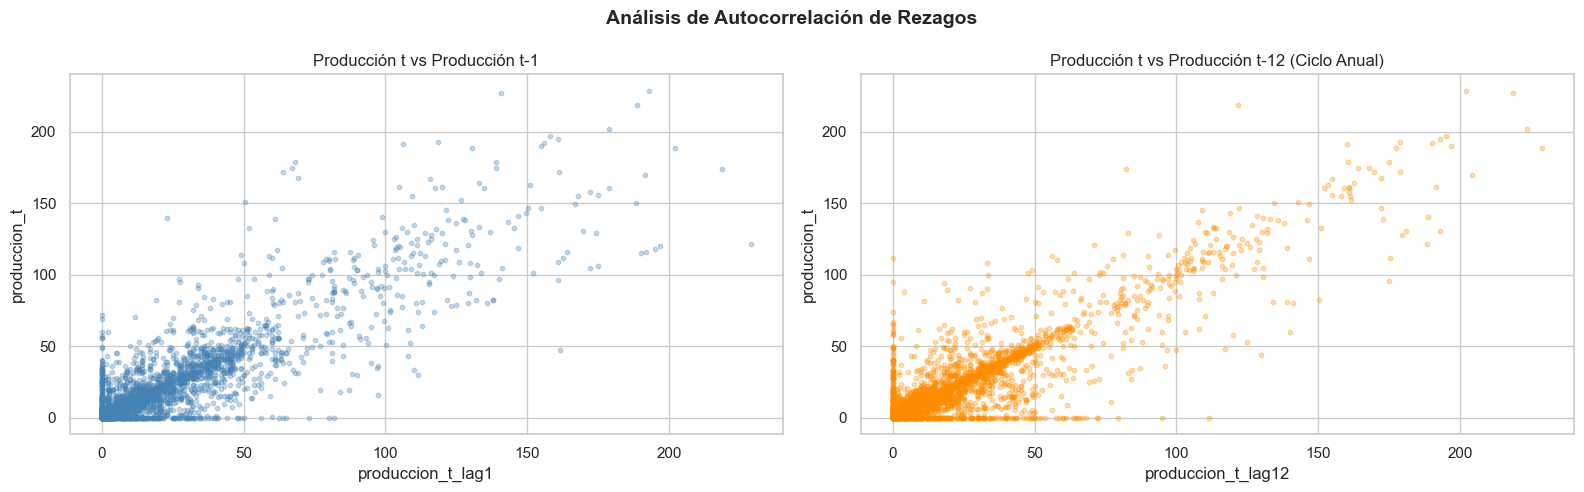

Gráfico guardado en data/processed/visualizacion_lags.png


In [7]:
if 'produccion_t' in df_clean.columns:
    from pandas.plotting import autocorrelation_plot

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Gráfico 1: Scatter lag-1 vs t
    axes[0].scatter(
        df_clean['produccion_t_lag1'],
        df_clean['produccion_t'],
        alpha=0.3, s=10, color='steelblue'
    )
    axes[0].set_title('Producción t vs Producción t-1', fontsize=12)
    axes[0].set_xlabel('produccion_t_lag1')
    axes[0].set_ylabel('produccion_t')

    # Gráfico 2: Scatter lag-12 vs t
    axes[1].scatter(
        df_clean['produccion_t_lag12'],
        df_clean['produccion_t'],
        alpha=0.3, s=10, color='darkorange'
    )
    axes[1].set_title('Producción t vs Producción t-12 (Ciclo Anual)', fontsize=12)
    axes[1].set_xlabel('produccion_t_lag12')
    axes[1].set_ylabel('produccion_t')

    plt.suptitle('Análisis de Autocorrelación de Rezagos', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../../data/processed/visualizacion_lags.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Gráfico guardado en data/processed/visualizacion_lags.png")
else:
    print("Columna 'produccion_t' no encontrada. Verifica el nombre en tu dataset.")


## 6. Exportar Dataset con Rezagos
Exportamos el dataset final con todas las columnas de rezago. Este archivo será la entrada de la **Actividad 04: Normalización y Escalado**.

In [8]:
df_clean.to_csv(OUTPUT_FILE, index=False)
print(f"✅ Dataset exportado exitosamente a: {OUTPUT_FILE}")
print(f"   Shape final: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas")
print(f"\nResumen de columnas generadas:")
print(f"  - Originales      : {df.shape[1] - len(lag_frames)}")
print(f"  - Nuevas (lag)    : {len(lag_frames)}")
print(f"  - Total final     : {df_clean.shape[1]}")
df_clean.head(3)


✅ Dataset exportado exitosamente a: ../../data/processed/master_dataset_fase2_lags.csv
   Shape final: 4,620 filas × 56 columnas

Resumen de columnas generadas:
  - Originales      : 20
  - Nuevas (lag)    : 36
  - Total final     : 56


,fecha_evento,departamento,provincia,produccion_t,cosecha_ha,precio_chacra_kg,num_emergencias,total_afectados,ALLSKY_SFC_SW_DWN,PRECTOTCORR,...,WS2M_lag6,WS2M_lag12,ALLSKY_SFC_SW_DWN_lag1,ALLSKY_SFC_SW_DWN_lag3,ALLSKY_SFC_SW_DWN_lag6,ALLSKY_SFC_SW_DWN_lag12,nlp_sentiment_lag1,nlp_sentiment_lag3,nlp_sentiment_lag6,nlp_sentiment_lag12
0,2022-01-01,APURIMAC,ABANCAY,24.0,0.0,1.250,22.0,132.0,17.88,138.88,...,1.32,1.28,18.56,20.44,19.05,17.71,0.548314,0.065579,0.042592,0.0
1,2022-02-01,APURIMAC,ABANCAY,5.0,0.0,1.000,34.0,197.0,16.75,381.64,...,1.53,1.18,17.88,18.00,19.50,18.20,1.244420,0.247121,1.832662,0.0
2,2022-03-01,APURIMAC,ABANCAY,28.0,0.0,1.225,25.0,39.0,17.73,122.14,...,1.73,1.16,16.75,18.56,18.19,16.69,1.154828,0.548314,0.143382,0.0
